# House Price Prediction — Regression Models

This notebook focuses on supervised regression modeling to predict house prices as continuous numerical values.
Regression is the most appropriate approach for this problem, as housing prices represent a continuous target variable that requires precise estimation.

In [1]:
import numpy as np
import pandas as pd
import time
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_val_predict, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import xgboost as xgb
from scipy.stats import friedmanchisquare
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [2]:
df_2 = pd.read_csv('../data/processed/df2.csv')

## 1. Data Loading & Train-Test Split
We start by loading the preprocessed dataset. Since the goal is to predict future house prices based on historical data, we split the data into a training set (80%) for model learning and a testing set (20%) for unseen data evaluation.

In [3]:
# Separate features (X) from the target variable (y)
X = df_2.drop(columns=['SalePrice'])
y = df_2['SalePrice']

# Split the dataset: 80% for training, 20% for testing
# random_state=42 ensures reproducibility across different runs
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")

Train size : (1092, 69)
Test size  : (273, 69)


## 2. Evaluation Metrics
For housing prices, the Root Mean Squared Logarithmic Error (RMSLE) is the standard and most robust metric. It penalizes relative errors rather than absolute errors, meaning a 10k CAD mistake on a 100k CAD house is treated more strictly than a 10k CAD mistake on a 1M CAD house. We also track RMSE and $R^2$ for a comprehensive evaluation. 

In [4]:
# Define a robust evaluation function computing multiple metrics
def regression_metrics(y_true, y_pred):
    # RMSLE: Calculates relative error, mitigating the impact of massive price outliers
    rmsle = np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))
    # RMSE: Standard absolute error metric
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    # R²: Proportion of variance in the target variable explained by the model
    r2    = r2_score(y_true, y_pred)
    
    return rmsle, rmse, r2

## 3. Baseline Linear Models
We establish a performance baseline using basic Linear Regression and Ridge Regression (which introduces L2 regularization to prevent overfitting). Because linear models are highly sensitive to feature magnitudes, we embed them in a `Pipeline` with a `StandardScaler`.

In [5]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=42)
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = []                # Final list to store summary metrics
cv_rmsle_scores = {}        # Stores CV scores for robustness analysis (boxplots)
train_times = {}            # Tracks training time per model

In [6]:
for name, base_model in models.items():
    print(f"\n================ {name} ================")

    # ----- Complete Pipeline -----
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", base_model),
    ])

    # Training Time
    t0 = time.time()
    pipe.fit(X_train, y_train)
    train_times[name] = time.time() - t0

    # Train Metrics
    y_pred_train = pipe.predict(X_train)
    rmsle_train, rmse_train, r2_train = regression_metrics(y_train, y_pred_train)

    # Test Metrics
    y_pred_test = pipe.predict(X_test)
    rmsle_test, rmse_test, r2_test = regression_metrics(y_test, y_pred_test)

    # CV Robustness (training data only)
    cv_rmsle = -cross_val_score(
        pipe, X_train, y_train,
        cv=kf,
        scoring=lambda mdl, Xv, yv: -np.sqrt(
            mean_squared_error(np.log1p(yv), np.log1p(mdl.predict(Xv)))
        )
    )
    cv_rmsle_scores[name] = cv_rmsle

    # Save Results
    results.append({
        "model": name,
        "RMSLE_train": rmsle_train,
        "RMSLE_test": rmsle_test,
        "RMSE_train": rmse_train,
        "RMSE_test": rmse_test,
        "R2_train": r2_train,
        "R2_test": r2_test,
        "Train_Time": train_times[name],
        "RMSLE_CV_mean": cv_rmsle.mean(),
        "RMSLE_CV_std": cv_rmsle.std()
    })

    print(f"Training time : {train_times[name]:.3f} sec")
    print(f"Train → RMSLE: {rmsle_train:.4f} | RMSE: {rmse_train:.2f} | R²: {r2_train:.4f}")
    print(f"Test  → RMSLE: {rmsle_test:.4f} | RMSE: {rmse_test:.2f} | R²: {r2_test:.4f}")
    print(f"CV Robustness RMSLE: mean={cv_rmsle.mean():.4f}, std={cv_rmsle.std():.4f}")


================ LinearRegression ================
Training time : 0.051 sec
Train → RMSLE: 0.1396 | RMSE: 23394.07 | R²: 0.9012
Test  → RMSLE: 0.1658 | RMSE: 25034.92 | R²: 0.8763
CV Robustness RMSLE: mean=0.1723, std=0.0455

================ Ridge ================
Training time : 0.008 sec
Train → RMSLE: 0.1403 | RMSE: 23397.55 | R²: 0.9012
Test  → RMSLE: 0.1656 | RMSE: 25037.68 | R²: 0.8762
CV Robustness RMSLE: mean=0.1754, std=0.0542


In [7]:
# Final Summary DataFrame for Reporting & Visualization

results_df = pd.DataFrame(results)
results_df.sort_values(by="RMSLE_test", ascending=False)

,model,RMSLE_train,RMSLE_test,RMSE_train,RMSE_test,R2_train,R2_test,Train_Time,RMSLE_CV_mean,RMSLE_CV_std
0,LinearRegression,0.139640,0.165795,23394.071716,25034.916156,0.901193,0.876271,0.050653,0.172318,0.045545
1,Ridge,0.140278,0.165625,23397.553756,25037.677167,0.901163,0.876244,0.008086,0.175356,0.054215


## 4. Advanced Ensemble Models
Tree-based ensemble models (Random Forest, XGBoost, LightGBM, and CatBoost) excel at capturing complex, non-linear relationships in tabular data. Unlike linear models, they do not strictly require feature scaling and are highly robust to outliers.

In [8]:
# Initialize a dictionary of powerful ensemble regressors with conservative baseline parameters
models_ensembles = {
    "RandomForest": RandomForestRegressor(
        n_estimators=1000,
        max_depth=None,
        max_features="sqrt",
        min_samples_leaf=1,
        n_jobs=-1,
        random_state=42
    ),

    "XGBoost": xgb.XGBRegressor(
        n_estimators=1000,
        learning_rate=0.01,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=1.0,
        objective="reg:squarederror",
        n_jobs=-1,
        random_state=42
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.01,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ),

    "CatBoost": CatBoostRegressor(
        iterations=1000,
        learning_rate=0.01,
        depth=4,
        loss_function="RMSE",
        random_state=42,
        verbose=0
    )
}

In [9]:
for name, model in models_ensembles.items():
    print(f"\n================ {name} ================")

    # Training Time
    t0 = time.time()
    model.fit(X_train, y_train)
    train_times[name] = time.time() - t0

    # Train Metrics
    y_pred_train = model.predict(X_train)
    rmsle_train, rmse_train, r2_train = regression_metrics(y_train, y_pred_train)

    # Test Metrics
    y_pred_test = model.predict(X_test)
    rmsle_test, rmse_test, r2_test = regression_metrics(y_test, y_pred_test)

    # CV Robustness (on training data)
    cv_rmsle = -cross_val_score(
        model, X_train, y_train,
        cv=kf,
        scoring=lambda mdl, Xv, yv: -np.sqrt(
            mean_squared_error(np.log1p(yv), np.log1p(mdl.predict(Xv)))
        )
    )
    cv_rmsle_scores[name] = cv_rmsle

    # =======================
    # E) Store Results
    # =======================
    results.append({
        "model": name,
        "RMSLE_train": rmsle_train,
        "RMSLE_test": rmsle_test,
        "RMSE_train": rmse_train,
        "RMSE_test": rmse_test,
        "R2_train": r2_train,
        "R2_test": r2_test,
        "Train_Time": train_times[name],
        "RMSLE_CV_mean": cv_rmsle.mean(),
        "RMSLE_CV_std": cv_rmsle.std()
    })

    print(f"Training time : {train_times[name]:.3f} sec")
    print(f"Train → RMSLE: {rmsle_train:.4f} | RMSE: {rmse_train:.2f} | R²: {r2_train:.4f}")
    print(f"Test  → RMSLE: {rmsle_test:.4f} | RMSE: {rmse_test:.2f} | R²: {r2_test:.4f}")
    print(f"CV Robustness RMSLE: mean={cv_rmsle.mean():.4f}, std={cv_rmsle.std():.4f}")


================ RandomForest ================
Training time : 0.910 sec
Train → RMSLE: 0.0514 | RMSE: 8749.77 | R²: 0.9862
Test  → RMSLE: 0.1490 | RMSE: 23354.22 | R²: 0.8923
CV Robustness RMSLE: mean=0.1321, std=0.0192

================ XGBoost ================
Training time : 0.909 sec
Train → RMSLE: 0.0575 | RMSE: 8898.29 | R²: 0.9857
Test  → RMSLE: 0.1325 | RMSE: 21086.02 | R²: 0.9122
CV Robustness RMSLE: mean=0.1199, std=0.0126

================ LightGBM ================
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001467 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4018
[LightGBM] [Info] Number of data points in the train set: 1092, number of used features: 69
[LightGBM] [Info] Start training from score 178085.339744
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001539 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM

### Models Summary & Comparison

In [10]:
results_df = pd.DataFrame(results)

# Sort by performance (mean CV RMSLE) to establish a logical order
results_df = results_df.sort_values("RMSLE_CV_mean").reset_index(drop=True)
display(results_df)

# Extract consistent model order based on ranking
models_list = results_df["model"].tolist()
print("Model Order:", models_list)

# Create a matrix (n_folds, n_models) of CV RMSLE scores
scores_per_model = [cv_rmsle_scores[m] for m in models_list]
scores_array = np.vstack(scores_per_model).T   # shape = (n_folds, n_models)
print("Scores Array Shape:", scores_array.shape)

,model,RMSLE_train,RMSLE_test,RMSE_train,RMSE_test,R2_train,R2_test,Train_Time,RMSLE_CV_mean,RMSLE_CV_std
0,XGBoost,0.057531,0.132522,8898.287476,21086.024945,0.985705,0.912226,0.908636,0.119950,0.012607
1,CatBoost,0.096792,0.132921,16164.947817,20790.310294,0.952823,0.914670,1.347905,0.120790,0.012631
2,LightGBM,0.036142,0.134183,7371.095096,20933.176704,0.990191,0.913494,1.689295,0.125544,0.012839
3,RandomForest,0.051424,0.149032,8749.774865,23354.223664,0.986178,0.892327,0.910025,0.132143,0.019154
4,LinearRegression,0.139640,0.165795,23394.071716,25034.916156,0.901193,0.876271,0.050653,0.172318,0.045545
5,Ridge,0.140278,0.165625,23397.553756,25037.677167,0.901163,0.876244,0.008086,0.175356,0.054215


Model Order: ['XGBoost', 'CatBoost', 'LightGBM', 'RandomForest', 'LinearRegression', 'Ridge']
Scores Array Shape: (5, 6)


## 5. Statistical Comparison 
### 5.1 Friedman Test Across All The Models
Simply comparing the mean Cross-Validation scores isn't enough to definitively say one model is superior to another. We use the non-parametric Friedman test to determine if the variance in model performances across the 5 folds is statistically significant.

In [11]:
# Execute the Friedman test across the CV scores of all models
friedman_stat, friedman_p = friedmanchisquare(*scores_array.T)

print("=== Friedman Test on RMSLE (5-fold CV) ===")
print(f"χ²_F Statistic : {friedman_stat:.4f}")
print(f"p-value        : {friedman_p:.6f}")

# Interpret the p-value at the 5% significance level
if friedman_p < 0.05:
    print(" Reject H0: At least one model performs significantly differently.")
else:
    print(" Fail to reject H0: No significant global difference between models.")

=== Friedman Test on RMSLE (5-fold CV) ===
χ²_F Statistic : 21.1143
p-value        : 0.000771
 Reject H0: At least one model performs significantly differently.


### 5.2 Friedman Test Across The Top 3 Models

In [12]:
# Extract consistent model order based on ranking
models_list = results_df["model"].tolist()
print("Model Order:", models_list)

# Create a matrix of shape (n_folds, n_models) containing CV RMSLE scores
scores_per_model = [cv_rmsle_scores[m] for m in models_list]
scores_array = np.vstack(scores_per_model).T   # shape = (n_folds, n_models)
print("Scores Array Shape:", scores_array.shape)

Model Order: ['XGBoost', 'CatBoost', 'LightGBM', 'RandomForest', 'LinearRegression', 'Ridge']
Scores Array Shape: (5, 6)


In [13]:
# Execute Friedman test to check for statistically significant differences across models
friedman_stat, friedman_p = friedmanchisquare(*scores_array.T)

print("=== Friedman Test on RMSLE (5-fold CV) ===")
print(f"χ²_F Statistic : {friedman_stat:.4f}")
print(f"p-value        : {friedman_p:.6f}")

# Interpret the p-value
if friedman_p < 0.05:
    print(" Reject H0: At least one model performs significantly differently.")
else:
    print(" Fail to reject H0: No significant global difference between models.")

=== Friedman Test on RMSLE (5-fold CV) ===
χ²_F Statistic : 21.1143
p-value        : 0.000771
 Reject H0: At least one model performs significantly differently.


## 6. Hyperparameter Tuning (GridSearchCV)
Having identified our top-performing base models (XGBoost and CatBoost), we perform an exhaustive grid search over specified parameter values. We define a custom RMSLE scorer to ensure the optimizer focuses on the metric that matters most for this specific business problem.

In [14]:
# Define custom RMSLE scorer for GridSearchCV
def rmsle_scorer(y_true, y_pred):
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))

# Set greater_is_better=False so GridSearchCV knows to minimize this value
rmsle_scorer_cv = make_scorer(rmsle_scorer, greater_is_better=False)

### 6.1 GridSearch For CatBoost

In [15]:
cat_model = CatBoostRegressor(
    loss_function="RMSE",
    random_seed=42,
    verbose=0
)

param_grid_cat = {
    "iterations": [500, 1000, 2000],
    "depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05],
    "subsample": [0.6, 0.8, 1.0]
}

grid_search_cat = GridSearchCV(
    estimator=cat_model,
    param_grid=param_grid_cat,
    scoring=rmsle_scorer_cv,  
    cv=kf,
    n_jobs=-1,
    verbose=1
)

# ---------------------------------------------------
# 1) Measure FULL GridSearch time
# ---------------------------------------------------
t0 = time.time()
grid_search_cat.fit(X_train, y_train)
grid_search_time_cat = time.time() - t0

print("\nCatBoost GridSearchCV completed.")
print(f"Full GridSearch time: {grid_search_time_cat:.3f} sec")
print("Best parameters found:")
print(grid_search_cat.best_params_)

# ---------------------------------------------------
# 2) Extract best model
# ---------------------------------------------------
best_cat = grid_search_cat.best_estimator_

# ---------------------------------------------------
# 3) Measure FINAL retraining time only
# ---------------------------------------------------
t0 = time.time()
best_cat.fit(X_train, y_train)
best_cat_train_time = time.time() - t0

print(f"Final retraining time of best CatBoost: {best_cat_train_time:.3f} sec")

# ---------------------------------------------------
# 4) Train metrics
# ---------------------------------------------------
y_pred_train = best_cat.predict(X_train)
rmsle_train, rmse_train, r2_train = regression_metrics(y_train, y_pred_train)

# ---------------------------------------------------
# 5) Test metrics
# ---------------------------------------------------
y_pred_test = best_cat.predict(X_test)
rmsle_test, rmse_test, r2_test = regression_metrics(y_test, y_pred_test)

# ---------------------------------------------------
# 6) CV robustness on training data
# ---------------------------------------------------
cv_rmsle = -cross_val_score(
    best_cat,
    X_train,
    y_train,
    cv=kf,
    scoring=rmsle_scorer_cv,
    n_jobs=-1
)

cv_rmsle_scores["CatBoost_GridSearch"] = cv_rmsle

# ---------------------------------------------------
# 7) Store results
# ---------------------------------------------------
results.append({
    "model": "CatBoost_GridSearch",
    "RMSLE_train": rmsle_train,
    "RMSLE_test": rmsle_test,
    "RMSE_train": rmse_train,
    "RMSE_test": rmse_test,
    "R2_train": r2_train,
    "R2_test": r2_test,
    "Train_Time": best_cat_train_time,
    "RMSLE_CV_mean": cv_rmsle.mean(),
    "RMSLE_CV_std": cv_rmsle.std()
})

# ---------------------------------------------------
# 8) Display results
# ---------------------------------------------------
print("\nMetrics for best CatBoost (GridSearchCV):")
print(f"Train -> RMSLE: {rmsle_train:.4f} | RMSE: {rmse_train:.2f} | R²: {r2_train:.4f}")
print(f"Test  -> RMSLE: {rmsle_test:.4f} | RMSE: {rmse_test:.2f} | R²: {r2_test:.4f}")
print(f"CV Robustness RMSLE: mean = {cv_rmsle.mean():.4f}, std = {cv_rmsle.std():.4f}")
print(f"Full GridSearch Time: {grid_search_time_cat:.3f} sec")
print(f"Final Retraining Time: {best_cat_train_time:.3f} sec")

Fitting 5 folds for each of 108 candidates, totalling 540 fits

CatBoost GridSearchCV completed.
Full GridSearch time: 2277.835 sec
Best parameters found:
{'depth': 6, 'iterations': 1000, 'learning_rate': 0.03, 'subsample': 0.6}
Final retraining time of best CatBoost: 2.452 sec

Metrics for best CatBoost (GridSearchCV):
Train -> RMSLE: 0.0416 | RMSE: 6178.35 | R²: 0.9931
Test  -> RMSLE: 0.1276 | RMSE: 19752.96 | R²: 0.9230
CV Robustness RMSLE: mean = 0.1127, std = 0.0107
Full GridSearch Time: 2277.835 sec
Final Retraining Time: 2.452 sec


In [16]:
# Updating the DataFrame
results_df = pd.DataFrame(results)
results_df.sort_values(by="RMSLE_test", ascending=True)

,model,RMSLE_train,RMSLE_test,RMSE_train,RMSE_test,R2_train,R2_test,Train_Time,RMSLE_CV_mean,RMSLE_CV_std
6,CatBoost_GridSearch,0.041597,0.127609,6178.354743,19752.958880,0.993108,0.922973,2.451732,0.112653,0.010689
3,XGBoost,0.057531,0.132522,8898.287476,21086.024945,0.985705,0.912226,0.908636,0.119950,0.012607
5,CatBoost,0.096792,0.132921,16164.947817,20790.310294,0.952823,0.914670,1.347905,0.120790,0.012631
4,LightGBM,0.036142,0.134183,7371.095096,20933.176704,0.990191,0.913494,1.689295,0.125544,0.012839
2,RandomForest,0.051424,0.149032,8749.774865,23354.223664,0.986178,0.892327,0.910025,0.132143,0.019154
1,Ridge,0.140278,0.165625,23397.553756,25037.677167,0.901163,0.876244,0.008086,0.175356,0.054215
0,LinearRegression,0.139640,0.165795,23394.071716,25034.916156,0.901193,0.876271,0.050653,0.172318,0.045545


### 6.2 GridSearch For XGBoost

In [17]:
xgb_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

param_grid_xgb = {
    "n_estimators": [1000, 3000, 5000],
    "max_depth": [4, 5, 6, 7, 8],
    "learning_rate": [0.01, 0.03, 0.05],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}

grid_search_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    scoring=rmsle_scorer_cv,  
    cv=kf,
    n_jobs=-1,
    verbose=1
)

# ---------------------------------------------------
# 1) Measure FULL GridSearch time
# ---------------------------------------------------
t0 = time.time()
grid_search_xgb.fit(X_train, y_train)
grid_search_time = time.time() - t0

print("\nGridSearchCV completed.")
print(f"Full GridSearch time: {grid_search_time:.3f} sec")
print("Best parameters found:")
print(grid_search_xgb.best_params_)

# ---------------------------------------------------
# 2) Extract best model
# ---------------------------------------------------
best_xgb = grid_search_xgb.best_estimator_

# ---------------------------------------------------
# 3) Measure FINAL retraining time only
# ---------------------------------------------------
t0 = time.time()
best_xgb.fit(X_train, y_train)
best_xgb_train_time = time.time() - t0

print(f"Final retraining time of best XGBoost: {best_xgb_train_time:.3f} sec")

# ---------------------------------------------------
# 4) Train metrics
# ---------------------------------------------------
y_pred_train = best_xgb.predict(X_train)
rmsle_train, rmse_train, r2_train = regression_metrics(y_train, y_pred_train)

# ---------------------------------------------------
# 5) Test metrics
# ---------------------------------------------------
y_pred_test = best_xgb.predict(X_test)
rmsle_test, rmse_test, r2_test = regression_metrics(y_test, y_pred_test)

# ---------------------------------------------------
# 6) CV robustness on training data
# ---------------------------------------------------
cv_rmsle = -cross_val_score(
    best_xgb,
    X_train,
    y_train,
    cv=kf,
    scoring=rmsle_scorer_cv,
    n_jobs=-1
)

cv_rmsle_scores["XGBoost_GridSearch"] = cv_rmsle

# ---------------------------------------------------
# 7) Store results
# ---------------------------------------------------
results.append({
    "model": "XGBoost_GridSearch",
    "RMSLE_train": rmsle_train,
    "RMSLE_test": rmsle_test,
    "RMSE_train": rmse_train,
    "RMSE_test": rmse_test,
    "R2_train": r2_train,
    "R2_test": r2_test,     
    "Train_Time": best_xgb_train_time,      
    "RMSLE_CV_mean": cv_rmsle.mean(),
    "RMSLE_CV_std": cv_rmsle.std()
})

# ---------------------------------------------------
# 8) Display results
# ---------------------------------------------------
print("\nMetrics for best XGBoost (GridSearchCV):")
print(f"Train -> RMSLE: {rmsle_train:.4f} | RMSE: {rmse_train:.2f} | R²: {r2_train:.4f}")
print(f"Test  -> RMSLE: {rmsle_test:.4f} | RMSE: {rmse_test:.2f} | R²: {r2_test:.4f}")
print(f"CV Robustness RMSLE: mean = {cv_rmsle.mean():.4f}, std = {cv_rmsle.std():.4f}")
print(f"Full GridSearch Time: {grid_search_time:.3f} sec")
print(f"Final Retraining Time: {best_xgb_train_time:.3f} sec")

Fitting 5 folds for each of 405 candidates, totalling 2025 fits

GridSearchCV completed.
Full GridSearch time: 1416.937 sec
Best parameters found:
{'colsample_bytree': 0.6, 'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 1000, 'subsample': 0.6}
Final retraining time of best XGBoost: 0.987 sec

Metrics for best XGBoost (GridSearchCV):
Train -> RMSLE: 0.0278 | RMSE: 4018.58 | R²: 0.9971
Test  -> RMSLE: 0.1276 | RMSE: 20202.57 | R²: 0.9194
CV Robustness RMSLE: mean = 0.1140, std = 0.0124
Full GridSearch Time: 1416.937 sec
Final Retraining Time: 0.987 sec


In [18]:
# Updating the DataFrame
results_df = pd.DataFrame(results)

In [19]:
results_df.to_csv("results_models_comparison.csv", index=False)
print(" File's Saved : results_models_comparison.csv")

 File's Saved : results_models_comparison.csv


In [20]:
results_df = pd.read_csv("results_models_comparison.csv")
results_df.sort_values(by="RMSLE_test", ascending=True)

,model,RMSLE_train,RMSLE_test,RMSE_train,RMSE_test,R2_train,R2_test,Train_Time,RMSLE_CV_mean,RMSLE_CV_std
7,XGBoost_GridSearch,0.027751,0.127562,4018.579724,20202.567758,0.997084,0.919427,0.987311,0.114046,0.012446
6,CatBoost_GridSearch,0.041597,0.127609,6178.354743,19752.958880,0.993108,0.922973,2.451732,0.112653,0.010689
3,XGBoost,0.057531,0.132522,8898.287476,21086.024945,0.985705,0.912226,0.908636,0.119950,0.012607
5,CatBoost,0.096792,0.132921,16164.947817,20790.310294,0.952823,0.914670,1.347905,0.120790,0.012631
4,LightGBM,0.036142,0.134183,7371.095096,20933.176704,0.990191,0.913494,1.689295,0.125544,0.012839
2,RandomForest,0.051424,0.149032,8749.774865,23354.223664,0.986178,0.892327,0.910025,0.132143,0.019154
1,Ridge,0.140278,0.165625,23397.553756,25037.677167,0.901163,0.876244,0.008086,0.175356,0.054215
0,LinearRegression,0.139640,0.165795,23394.071716,25034.916156,0.901193,0.876271,0.050653,0.172318,0.045545


## 7. Final Comparison & Trade-Off Analysis

C:\Users\aminl\AppData\Local\Temp\ipykernel_21584\952857435.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(cv_rmsle_data, labels=models_list)
C:\Users\aminl\AppData\Local\Temp\ipykernel_21584\952857435.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models_list, rotation=25)


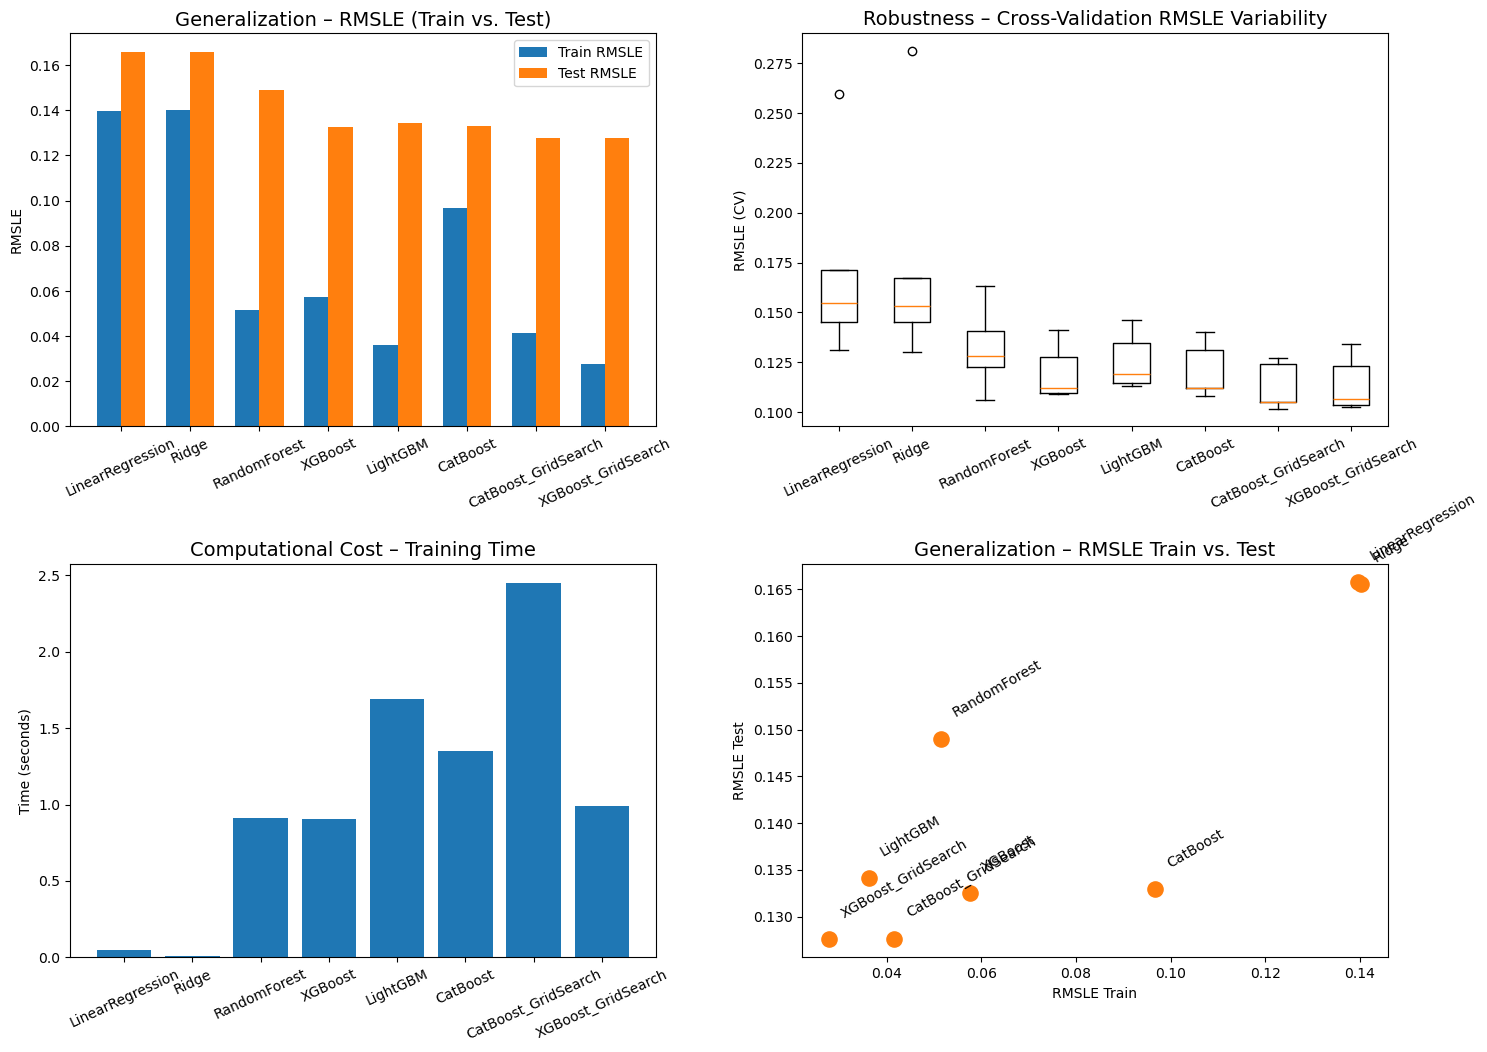

In [21]:
# ==============================================================
# Data Preparation
# ==============================================================

models_list = results_df["model"].tolist()

# Train/Test RMSLE
rmsle_train_values = results_df["RMSLE_train"].tolist()
rmsle_test_values = results_df["RMSLE_test"].tolist()

# Training time
train_time_values = results_df["Train_Time"].tolist()

# CV RMSLE Robustness (dict → list)
cv_rmsle_data = [cv_rmsle_scores[m] for m in models_list]

# ==============================================================
# Creating the 2x2 Canvas (Subplots)
# ==============================================================

fig, axes = plt.subplots(2, 2, figsize=(17, 12))
plt.subplots_adjust(hspace=0.35, wspace=0.25)

# ==============================================================
# 1️⃣ Plot 1: Train vs. Test RMSLE
# ==============================================================

ax = axes[0, 0]
x = np.arange(len(models_list))
width = 0.35

ax.bar(x - width/2, rmsle_train_values, width, label='Train RMSLE', color="#1f77b4")
ax.bar(x + width/2, rmsle_test_values, width, label='Test RMSLE', color="#ff7f0e")

ax.set_title("Generalization – RMSLE (Train vs. Test)", fontsize=14)
ax.set_ylabel("RMSLE")
ax.set_xticks(x)
ax.set_xticklabels(models_list, rotation=25)
ax.legend()

# ==============================================================
# 2️⃣ Plot 2: Robustness – CV RMSLE Variability
# ==============================================================

ax = axes[0, 1]
ax.boxplot(cv_rmsle_data, labels=models_list)

ax.set_title("Robustness – Cross-Validation RMSLE Variability", fontsize=14)
ax.set_ylabel("RMSLE (CV)")
ax.set_xticklabels(models_list, rotation=25)

# ==============================================================
# 3️⃣ Plot 3: Computational Cost (Training Time)
# ==============================================================

ax = axes[1, 0]
ax.bar(models_list, train_time_values, color="#1f77b4")

ax.set_title("Computational Cost – Training Time", fontsize=14)
ax.set_ylabel("Time (seconds)")
ax.set_xticklabels(models_list, rotation=25)

# ==============================================================
# 4️⃣ Plot 4: Generalization Scatter (Train vs. Test RMSLE)
# ==============================================================

ax = axes[1, 1]
ax.scatter(rmsle_train_values, rmsle_test_values, s=120, color="#ff7f0e")

# Adding model labels
for i, label in enumerate(models_list):
    ax.text(rmsle_train_values[i] + 0.002, rmsle_test_values[i] + 0.002, label, rotation=30, ha='left', va='bottom')

ax.set_title("Generalization – RMSLE Train vs. Test", fontsize=14)
ax.set_xlabel("RMSLE Train")
ax.set_ylabel("RMSLE Test")

# ==============================================================
plt.show()

In this final section, we visually compare the generalized performance of our tuned models. We evaluate the trade-offs between computational cost (training time), model complexity, and predictive accuracy (RMSLE/$R^2$) to make our final model selection.

From a business perspective, prediction stability is often more valuable than marginal accuracy gains. A model that generalizes well and produces consistent estimates across all price brackets is preferable for real-estate valuation decisions.

### Final Choice

Therefore, despite a slightly higher computational cost, we consider CatBoost (GridSearch) to be the best model to select, given its lower loss levels, robustness, and superior R²_test(0.9230) compared to the other models.

However, if computational power is a significant constraint, XGBoost (GridSearch) appears to be the best overall alternative.